In [11]:
# Load single timepoint ones

from glob import glob
from pathlib import Path
from re import findall
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt


In [12]:
# filelist

In [150]:

# dirname = Path('/Users/xies/OneDrive - Stanford/Skin/Two photon/NMS/Palbo senescence/11-01-2025 H2B FUCCI Palbo/M1 cage 5971/')
# expt_name = ['Left ear/R2','Right ear/R2']

dirname = Path('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Palbo senescence/F5 - 11-18-2025 H2B FUCCI Palbo-PG-DEGEE/M1')
expt_name = ['Left ear/R2','Right ear/R2']

filelist = list(dirname.rglob( f'{expt_name[0]}/**/mean_curvature_kappa10.npz'))
filelist = filelist + list(dirname.rglob( f'{expt_name[1]}/**/mean_curvature_kappa10.npz'))

# Parse filename for time signature
manifest = pd.DataFrame()
manifest['filename'] = filelist
manifest['dirname'] = manifest['filename'].apply(lambda x: x.parent)
manifest['subdir_name'] = manifest['filename'].apply(lambda x: str(x.parent.name))
manifest['Delay'] = manifest['subdir_name'].apply(lambda x: int(findall(r'(\d+). Day (\d+)',x)[0][1]))
manifest['Region'] = manifest['filename'].apply(lambda x: x.parents[1].name)
manifest['Mouse'] = manifest['filename'].apply(lambda x: x.parents[2].name)
manifest['Experiment'] = manifest['filename'].apply(lambda x: x.parents[3].name)

manifest['Mouse_Region'] = manifest['Mouse'] + '_' + manifest['Region']
manifest['name'] = manifest['Mouse'] + '_' + manifest['Region'] + '_t' + manifest['Delay'].astype(str)
print(manifest)

curvatures = {}
for idx, row in manifest.iterrows():
    curvatures[row['Mouse_Region'], row['Delay']] = np.load(row['filename'])['mean_curvature']

# [x.shape for x in curvatures.values()]

                                             filename  \
0   /Users/xies/Library/CloudStorage/OneDrive-Stan...   
1   /Users/xies/Library/CloudStorage/OneDrive-Stan...   
2   /Users/xies/Library/CloudStorage/OneDrive-Stan...   
3   /Users/xies/Library/CloudStorage/OneDrive-Stan...   
4   /Users/xies/Library/CloudStorage/OneDrive-Stan...   
5   /Users/xies/Library/CloudStorage/OneDrive-Stan...   
6   /Users/xies/Library/CloudStorage/OneDrive-Stan...   
7   /Users/xies/Library/CloudStorage/OneDrive-Stan...   
8   /Users/xies/Library/CloudStorage/OneDrive-Stan...   
9   /Users/xies/Library/CloudStorage/OneDrive-Stan...   
10  /Users/xies/Library/CloudStorage/OneDrive-Stan...   
11  /Users/xies/Library/CloudStorage/OneDrive-Stan...   
12  /Users/xies/Library/CloudStorage/OneDrive-Stan...   
13  /Users/xies/Library/CloudStorage/OneDrive-Stan...   

                                              dirname subdir_name  Delay  \
0   /Users/xies/Library/CloudStorage/OneDrive-Stan...    1. Day 1   

In [164]:
p

,note,translation_y_px,translation_x_px,rotation_deg,scale_y,scale_x,shear
layer,,,,,,,
t0,absolute (world coords),0.000000,0.000000,0.000000,1.0,1.0,0.0
t1,relative to 't0',0.000000,0.000000,0.000000,1.0,1.0,0.0
t2,relative to 't0',-12.030200,12.320042,-1.363928,1.0,1.0,0.0
t3,relative to 't0',-14.130441,23.749465,-2.021365,1.0,1.0,1.0
t4,relative to 't0',-9.299484,22.309413,-1.669958,1.0,1.0,0.0
t5,relative to 't0',-79.922830,25.931366,-6.749175,1.0,1.0,0.0
t6,relative to 't0',-41.725821,28.344257,-4.230151,1.0,1.0,0.0


In [201]:
# Use manual napari alignment params
from skimage import transform, io
from skimage.transform import AffineTransform, warp
from collections import defaultdict

Xtrim = slice(400,700)
Ytrim = slice(400,700)

registration_file = {'Right ear_R2':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Palbo senescence/F5 - 11-18-2025 H2B FUCCI Palbo-PG-DEGEE/M1/Right ear/R2/registration_params.csv',
                    'Left ear_R2':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Palbo senescence/F5 - 11-18-2025 H2B FUCCI Palbo-PG-DEGEE/M1/Left ear/R2/registration_params.csv'}

SWAP = np.array([[0, 1, 0], [1, 0, 0], [0, 0, 1]], float)
def napari_affine(r):
    """napari (y,x) Translate @ Rotate @ Shear @ Scale -> skimage (x,y) matrix"""
    th = np.deg2rad(r.rotation_deg)
    T = np.array([[1, 0, r.translation_y_px], [0, 1, r.translation_x_px], [0, 0, 1]])
    R = np.array([[np.cos(th), -np.sin(th), 0], [np.sin(th), np.cos(th), 0], [0, 0, 1]])
    H = np.array([[1, r.shear, 0], [0, 1, 0], [0, 0, 1]])
    S = np.array([[r.scale_y, 0, 0], [0, r.scale_x, 0], [0, 0, 1]])
    return SWAP @ (T @ R @ H @ S) @ SWAP

curvatures_aligned = {}
delays = defaultdict(list)
for _,row in manifest.iterrows():
    name = row['Mouse_Region']
    delay = row['Delay']
    p = pd.read_csv(registration_file[name],index_col=0)
    if delay == 0:
        curvatures_aligned[(name,0)] = curvatures[(name,0)]
        continue
    else:
        r = p.loc[f't{delay}']
        tf = AffineTransform(matrix=napari_affine(r))
        transformed = warp(curvatures[(name,delay)], tf.inverse, order=1,
                           preserve_range=True).astype(curvatures[(name,delay)].dtype)
    T = transform.EuclideanTransform(T)
    
    curvatures_aligned[(name,delay)] = transformed
    # delays[mouse].append(row['Delay'])
    io.imsave( row['dirname'] / 'aligned_curvature.tif', transformed)
    

In [151]:
# Align and save aligned - auto
# from pystackreg import StackReg
# from skimage import transform, io
# from collections import defaultdict

# Xtrim = slice(400,700)
# Ytrim = slice(400,700)

# curvatures_aligned = {}
# delays = defaultdict(list)
# for _,row in manifest.iterrows():
#     # valid_delays = manifest.set_index('Mouse_Region').loc[name]['Delay']
#     # for delay in valid_delays:
#     name = row['Mouse_Region']
#     delay = row['Delay']
#     if delay == 0:
#         curvatures_aligned[(name,0)] = curvatures[(name,0)]
#         continue
#     else:
#         sr = StackReg(StackReg.RIGID_BODY)
#         T = sr.register(curvatures[(name,0)][Xtrim,Ytrim],
#                     curvatures[(name,delay)][Xtrim,Ytrim])
    
#     T = transform.EuclideanTransform(T)
    
#     transformed = transform.warp(curvatures[(name,delay)],T)
#     # transformed = sr.transform(curvatures[(name,delay)])
#     curvatures_aligned[(name,delay)] = transformed
#     # delays[mouse].append(row['Delay'])
#     io.imsave( row['dirname'] / 'aligned_curvature.tif', transformed)
    

In [202]:
from mathUtils import normxcorr2
from itertools import product
correlations_by_mouse = {}

for mouse in ['Right ear_R2','Left ear_R2']:
    correlation_matrix = [normxcorr2(curvatures_aligned[(mouse,tau)][Ytrim,Xtrim],
                          curvatures_aligned[(mouse,upsilon)][Ytrim,Xtrim]
                          ).max()
                          for tau in range(7) for upsilon in range(7)]
    correlation_matrix = np.array(correlation_matrix).reshape(7,7)
    correlations_by_mouse[mouse] = correlation_matrix


In [186]:
# manifest

In [203]:
np.savez(dirname / 'Right Ear/R2/curvature_correlations.npz',C = correlations_by_mouse['Right ear_R2'])
np.savez(dirname / 'Left Ear/R2/curvature_correlations.npz',C = correlations_by_mouse['Left ear_R2'])

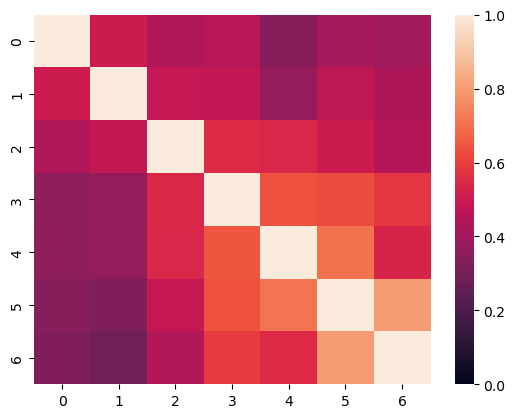

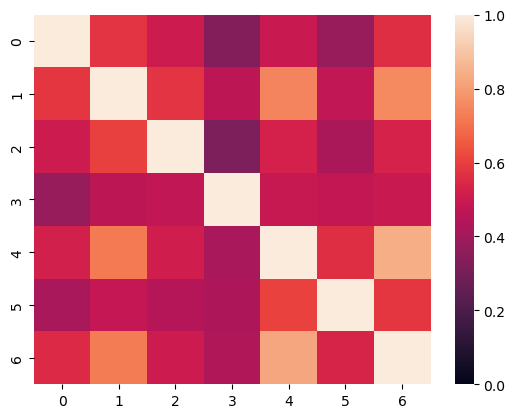

In [204]:
sb.heatmap(correlations_by_mouse['Left ear_R2'],vmin=0,vmax=1)
plt.savefig(dirname/ 'Left ear/R2' / 'curvature_persistence_by_delay.svg')
plt.figure()
sb.heatmap(correlations_by_mouse['Right ear_R2'],vmin=0,vmax=1)
plt.savefig(dirname/ 'Right ear/R2' / 'curvature_persistence_by_delay.svg')

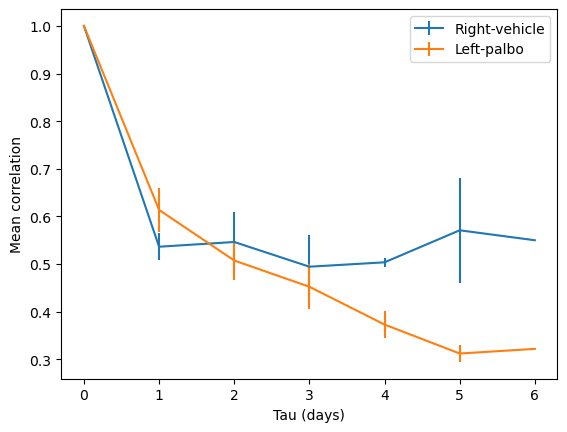

In [208]:
from itertools import product

diffs = np.array([tau - upsilon for tau in range(7) for upsilon in range(7)]).reshape((7,7)).astype(float)
diffs[diffs < 0] = np.nan
# diffs[:,1] = np.nan
# diffs[1,:] = np.nan

correlations_by_mouse_delay = {}
stds_by_mouse_delay = {}
for mouse in ['Right ear_R2','Left ear_R2']:
    R = np.zeros(7)
    sem = np.zeros(7)
    for delay in range(7):
        I = diffs == delay
        R[delay] = correlations_by_mouse[mouse][I].mean()
        sem[delay] = correlations_by_mouse[mouse][I].std() / np.sqrt(I.sum())
    correlations_by_mouse_delay[mouse] = R
    stds_by_mouse_delay[mouse] = sem

plt.errorbar(range(7),correlations_by_mouse_delay['Right ear_R2'],stds_by_mouse_delay['Right ear_R2'])
plt.errorbar(range(7),correlations_by_mouse_delay['Left ear_R2'],stds_by_mouse_delay['Left ear_R2'])
plt.legend(['Right-vehicle','Left-palbo'])
plt.xlabel('Tau (days)')
plt.ylabel('Mean correlation')

plt.savefig(dirname / 'curvature_persistence_by_delay.svg')

In [209]:
palbo_1 = np.load('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Palbo senescence/11-01-2025 H2B FUCCI Palbo/M1 cage 5971/Left ear/R2/curvature_correlations.npz')['C']
palbo_2 = np.load('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Palbo senescence/F5 - 11-18-2025 H2B FUCCI Palbo-PG-DEGEE/M1/Left ear/R2/curvature_correlations.npz')['C']

ctrl_1 = np.load('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Palbo senescence/11-01-2025 H2B FUCCI Palbo/M1 cage 5971/Right ear/R2/curvature_correlations.npz')['C']
ctrl_2 = np.load('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Palbo senescence/F5 - 11-18-2025 H2B FUCCI Palbo-PG-DEGEE/M1/Right ear/R2/curvature_correlations.npz')['C']


In [210]:
palbo_1[0,6]
# palbo_2.shape

np.float64(0.6003716592773817)

In [ ]:
from itertools import product

diffs = np.array([tau - upsilon for tau in range(7) for upsilon in range(7)]).reshape((7,7)).astype(float)
diffs[diffs < 0] = np.nan
# diffs[:,1] = np.nan
# diffs[1,:] = np.nan

correlations_by_mouse_delay = {}
stds_by_mouse_delay = {}
for mouse,corr in {'palbo1':palbo_1,'palbo_2':palbo_2,'ctrl_1':ctrl_1,'ctrl_2':ctrl_2}.items():
    R = np.zeros(7)
    sem = np.zeros(7)
    for delay in range(7):
        I = diffs == delay
        R[delay] = corr[I].mean()
        sem[delay] = corr[I].std() / np.sqrt(I.sum())
    correlations_by_mouse_delay[mouse] = R
    stds_by_mouse_delay[mouse] = sem

C = pd.DataFrame(correlations_by_mouse_delay).T
C['Treatment'] = ['Palbo','Palbo','Ctrl','Ctrl']
C['Rep']= [1,1,2,2]
C = C.melt(id_vars = ['Treatment','Rep'],value_vars = range(6),var_name='Delay',value_name='Correlation')

sb.lineplot(C[C['Delay'] > 0],x='Delay',y='Correlation',hue='Treatment')